# Baseline Borůvka CL — per-phase profiler

Goal: measure where the **unoptimized** baseline `boruvka_mst_cl` from `fast_hdbscan/core_graph.py` actually spends its time, then use the breakdown to decide which optimizations are worth pursuing.

Phases timed (mirrors the loop in [core_graph.py](fast_hdbscan/core_graph.py) `boruvka_mst_cl`):

| Phase | What it does |
|---|---|
| `root_snap` | Path-compressed root snapshot before phase 1 |
| `select`    | `select_components_cl` — per-vertex cheapest-edge scan + mutual-proposal selection |
| `band`      | Optional band filtering (no-op when `band_fraction = inf`) |
| `validate`  | `validate_and_prune_merges` — BFS over candidate-edge graph for CL feasibility |
| `commit`    | DSU union + CL list merge for surviving edges |
| `update`    | `update_point_components` + `update_graph_components` — full-vertex sweeps |

Wrapper cost is a few µs per round (negligible vs. the work).


## 1. Setup — load only the baseline `core_graph` (no optimization variants)


In [1]:
import shutil, glob, sys, os, importlib.util, types, time
import numpy as np
import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.metrics import pairwise_distances

# Clear stale __pycache__ from prior runs / module-loader experiments
for d in glob.glob(os.path.join(os.getcwd(), '**', '__pycache__'), recursive=True):
    if '.venv' not in d:
        shutil.rmtree(d, ignore_errors=True)

# Bypass __init__.py JIT warmup so we can load core_graph cleanly without dragging
# in the optimization variants
_pkg_dir = os.path.join(os.getcwd(), 'fast_hdbscan')
_stub = types.ModuleType('fast_hdbscan')
_stub.__path__ = [_pkg_dir]
_stub.__package__ = 'fast_hdbscan'
sys.modules['fast_hdbscan'] = _stub

def _load(mod_name):
    spec = importlib.util.spec_from_file_location(
        f'fast_hdbscan.{mod_name}',
        os.path.join(_pkg_dir, f'{mod_name}.py'),
        submodule_search_locations=[_pkg_dir],
    )
    mod = importlib.util.module_from_spec(spec)
    sys.modules[f'fast_hdbscan.{mod_name}'] = mod
    spec.loader.exec_module(mod)
    return mod

_load('variables')
_load('disjoint_set')
_load('numba_kdtree')
_load('cluster_trees')
_cg   = _load('core_graph')      # the BASELINE — no opts loaded
_prec = _load('precomputed')

# Pull baseline helpers
CoreGraph                  = _cg.CoreGraph
boruvka_mst_cl             = _cg.boruvka_mst_cl  # baseline, untouched
select_components_cl       = _cg.select_components_cl
validate_and_prune_merges  = _cg.validate_and_prune_merges
update_point_components    = _cg.update_point_components
update_graph_components    = _cg.update_graph_components
_init_cl_pool              = _cg._init_cl_pool
_merge_cl_lists            = _cg._merge_cl_lists

_ds = sys.modules['fast_hdbscan.disjoint_set']
ds_rank_create = _ds.ds_rank_create
ds_find        = _ds.ds_find

_symmetrize_min_csr   = _prec._symmetrize_min_csr
_core_distances_csr   = _prec._core_distances_csr
_build_core_graph_csr = _prec._build_core_graph_csr

import numba
print(f'numba threads = {numba.get_num_threads()}')
print('Baseline core_graph loaded (no opt variants).')


numba threads = 8
Baseline core_graph loaded (no opt variants).


## 2. Helpers — geometry generators and CL pair sampler


In [2]:
SEED = 42
MS = 5

def make_cl_matrix(n, pairs):
    rows, cols = [], []
    for i, j in pairs:
        rows += [i, j]; cols += [j, i]
    return sp.csr_matrix((np.ones(len(rows), dtype=np.int8), (rows, cols)), shape=(n, n))

def generate_cl_pairs(y, n_pairs, seed=SEED):
    rng = np.random.default_rng(seed)
    classes = np.unique(y)
    pairs = set()
    for _ in range(n_pairs * 10):
        if len(pairs) >= n_pairs:
            break
        cls = rng.choice(classes)
        idx = np.where(y == cls)[0]
        if len(idx) < 2:
            continue
        i, j = rng.choice(idx, 2, replace=False)
        pairs.add((min(int(i), int(j)), max(int(i), int(j))))
    return sorted(pairs)

def gen_pinwheel(n, seed=SEED):
    rng = np.random.default_rng(seed)
    n_arms, Xs, ys = 5, [], []
    per_arm = n // n_arms
    for k in range(n_arms):
        m = per_arm + (1 if k < n % n_arms else 0)
        t = np.linspace(0, 1, m)
        angle = 2 * np.pi * k / n_arms
        r = 0.3 + 0.7 * t
        theta = angle + t * 1.5
        x = r * np.cos(theta) + rng.normal(0, 0.04, m)
        yy = r * np.sin(theta) + rng.normal(0, 0.04, m)
        Xs.append(np.column_stack([x, yy]))
        ys.append(np.full(m, k, dtype=np.int64))
    return np.vstack(Xs).astype(np.float64), np.concatenate(ys)

def gen_two_moons(n, seed=SEED):
    X, y = make_moons(n_samples=n, noise=0.08, random_state=seed)
    return X.astype(np.float64), y.astype(np.int64)

def gen_chain(n, seed=SEED):
    rng = np.random.default_rng(seed)
    k = 4
    per = n // k
    Xs, ys = [], []
    for i in range(k):
        m = per + (1 if i < n % k else 0)
        center = np.array([i * 2.5, 0.0])
        Xs.append(rng.normal(center, 0.5, (m, 2)))
        ys.append(np.full(m, i, dtype=np.int64))
    return np.vstack(Xs).astype(np.float64), np.concatenate(ys)

GEOMETRIES = {'pinwheel': gen_pinwheel, 'two_moons': gen_two_moons, 'chain': gen_chain}

def build_core_graph(X, ms=MS):
    D = pairwise_distances(X, metric='euclidean').astype(np.float32)
    D_sparse = sp.csr_matrix(D)
    X_sym = _symmetrize_min_csr(D_sparse)
    _, core_dists = _core_distances_csr(
        X_sym.data, X_sym.indices, X_sym.indptr, ms)
    weights, distances, cg_indices = _build_core_graph_csr(
        X_sym.data, X_sym.indices, X_sym.indptr, core_dists)
    return CoreGraph(weights, distances, cg_indices, X_sym.indptr)

def make_inputs(geo, n, frac_cl):
    X, y = GEOMETRIES[geo](n)
    n_cl = max(3, int(n * frac_cl))
    pairs = generate_cl_pairs(y, n_cl)
    cls = make_cl_matrix(n, pairs)
    return (build_core_graph(X),
            np.asarray(cls.indices, dtype=np.int32),
            np.asarray(cls.indptr,  dtype=np.int64),
            len(pairs))

print('Helpers ready.')


Helpers ready.


## 3. Instrumented baseline — `boruvka_mst_cl_profiled`

Python-level mirror of the `while n_components > 1:` loop in [core_graph.py](fast_hdbscan/core_graph.py#L696). It calls each Numba helper exactly as the baseline does, with `time.perf_counter()` between phases. Output is identical to the baseline; only the wrapper is different.


In [3]:
PHASES = ('root_snap', 'select', 'band', 'validate', 'commit', 'update')


def boruvka_mst_cl_profiled(graph, cl_indices, cl_indptr, band_fraction=np.inf):
    """Instrumented mirror of baseline boruvka_mst_cl. Returns (edges, n_rounds, totals)."""
    distances = graph.weights.copy()
    indices   = graph.indices.copy()
    indptr    = graph.indptr

    n = len(indptr) - 1
    disjoint_set = ds_rank_create(n)
    point_components = np.arange(n, dtype=np.int32)
    n_components = n

    pool_vertex, pool_next, comp_head, comp_tail, comp_csize = _init_cl_pool(
        cl_indices, cl_indptr, n)

    edges_list = []
    use_banding = band_fraction < 1e30
    n_rounds = 0

    max_adj = 2 * n
    _adj_head      = np.full(n, -1, dtype=np.int32)
    _adj_next      = np.empty(max_adj, dtype=np.int32)
    _adj_edge_idx  = np.empty(max_adj, dtype=np.int32)
    _bfs_queue        = np.empty(n, dtype=np.int32)
    _bfs_parent_edge  = np.full(n, -1, dtype=np.int32)
    _bfs_visited      = np.zeros(n, dtype=np.bool_)
    _temp_parent      = np.arange(n, dtype=np.int32)
    compressed_roots  = np.arange(n, dtype=np.int32)

    totals = {k: 0.0 for k in PHASES}

    while n_components > 1:
        # P0 root snapshot
        t0 = time.perf_counter()
        for i in range(n):
            r = disjoint_set.parent[i]
            while disjoint_set.parent[r] != r:
                r = disjoint_set.parent[r]
            compressed_roots[i] = r
        t1 = time.perf_counter(); totals['root_snap'] += t1 - t0

        # P1+2 select
        cand_src, cand_dst, cand_wt, n_cand = select_components_cl(
            distances, indices, indptr, point_components,
            comp_head, comp_csize, pool_vertex, pool_next, compressed_roots)
        t2 = time.perf_counter(); totals['select'] += t2 - t1
        if n_cand == 0:
            break

        # P_band
        if use_banding:
            w_min = cand_wt[:n_cand].min()
            band_hi = w_min * (1.0 + band_fraction)
            mask = cand_wt[:n_cand] <= band_hi
            k = int(mask.sum())
            cand_src[:k] = cand_src[:n_cand][mask]
            cand_dst[:k] = cand_dst[:n_cand][mask]
            cand_wt[:k]  = cand_wt[:n_cand][mask]
            n_cand = k
        t3 = time.perf_counter(); totals['band'] += t3 - t2

        # P3 validate
        surv_src, surv_dst, surv_wt, n_surviving = validate_and_prune_merges(
            cand_src, cand_dst, cand_wt, n_cand,
            cl_indices, cl_indptr, point_components, n,
            _adj_head, _adj_next, _adj_edge_idx,
            _bfs_queue, _bfs_parent_edge, _bfs_visited, _temp_parent)
        t4 = time.perf_counter(); totals['validate'] += t4 - t3
        if n_surviving == 0:
            break

        # P4 commit
        new_edges = np.empty((n_surviving, 3), dtype=np.float64)
        n_added = 0
        for i in range(n_surviving):
            src = int(surv_src[i]); dst = int(surv_dst[i])
            rs = ds_find(disjoint_set, src)
            rd = ds_find(disjoint_set, dst)
            if rs != rd:
                new_edges[n_added, 0] = src
                new_edges[n_added, 1] = dst
                new_edges[n_added, 2] = surv_wt[i]
                n_added += 1
                if disjoint_set.rank[rs] > disjoint_set.rank[rd]:
                    new_root, old_root = rs, rd
                elif disjoint_set.rank[rs] < disjoint_set.rank[rd]:
                    new_root, old_root = rd, rs
                else:
                    new_root, old_root = rs, rd
                    disjoint_set.rank[new_root] += 1
                disjoint_set.parent[old_root] = new_root
                _merge_cl_lists(new_root, old_root, comp_head, comp_tail,
                                comp_csize, pool_next)
        t5 = time.perf_counter(); totals['commit'] += t5 - t4
        if n_added == 0:
            break
        edges_list.append(new_edges[:n_added])

        # P5 update
        update_point_components(disjoint_set, point_components)
        update_graph_components(distances, indices, indptr, point_components)
        t6 = time.perf_counter(); totals['update'] += t6 - t5

        n_components -= n_added
        n_rounds += 1

    num_edges = sum(e.shape[0] for e in edges_list)
    result = np.empty((num_edges, 3), dtype=np.float64)
    c = 0
    for e in edges_list:
        result[c:c+e.shape[0]] = e; c += e.shape[0]
    return result, n_rounds, totals


# Warm-up: trigger Numba JIT for select/validate/update on float64/int32 specializations
print('Warming up JIT (one small run per geometry)...')
for geo in GEOMETRIES:
    cg, cli, clp, _ = make_inputs(geo, 200, 0.05)
    _ = boruvka_mst_cl_profiled(cg, cli, clp)
print('Warmup done.')


Warming up JIT (one small run per geometry)...
Warmup done.


## 4. Profiling sweep

Sweep over (geometry, n, CL density). 5 repeats per point; report the mean per-phase totals.


In [4]:
REPEATS = 5

PROFILE_POINTS = [
    # (label,           geometry,   n,    frac_cl)
    ('small_sparse',   'pinwheel',  500,  0.05),
    ('small_dense',    'pinwheel',  500,  0.40),
    ('medium_sparse',  'pinwheel',  3000, 0.05),
    ('medium_dense',   'pinwheel',  3000, 0.40),
    ('large_sparse',   'pinwheel',  7500, 0.05),
    ('two_moons_med',  'two_moons', 3000, 0.05),
    ('chain_med',      'chain',     3000, 0.05),
]

rows = []
for label, geo, n, frac in PROFILE_POINTS:
    cg, cli, clp, n_cl = make_inputs(geo, n, frac)
    # one warm pass at this size
    _ = boruvka_mst_cl_profiled(cg, cli, clp)

    agg = {k: 0.0 for k in PHASES}
    n_rounds_obs = []
    for _ in range(REPEATS):
        _, nr, totals = boruvka_mst_cl_profiled(cg, cli, clp)
        for k in PHASES:
            agg[k] += totals[k]
        n_rounds_obs.append(nr)
    for k in PHASES:
        agg[k] /= REPEATS
    total = sum(agg.values())

    row = {'label': label, 'geo': geo, 'n': n, 'frac_cl': frac, 'n_cl': n_cl,
           'n_rounds': int(np.median(n_rounds_obs)), 'total_ms': total * 1000}
    for k in PHASES:
        row[f'{k}_ms']  = agg[k] * 1000
        row[f'{k}_pct'] = 100 * agg[k] / total if total > 0 else 0.0
    rows.append(row)
    print(f"  done {label:>15}  n={n:>5}  frac={frac:.2f}  total={total*1000:7.1f} ms")

prof_df = pd.DataFrame(rows)

ms_cols = ['label','n','frac_cl','n_rounds','total_ms'] + [f'{k}_ms' for k in PHASES]
print('\n=== Per-phase wall-clock (ms, mean of 5) ===')
print(prof_df[ms_cols].round(2).to_string(index=False))

pct_cols = ['label','n','frac_cl','total_ms'] + [f'{k}_pct' for k in PHASES]
print('\n=== Phase share (% of total) ===')
print(prof_df[pct_cols].round(1).to_string(index=False))


  done    small_sparse  n=  500  frac=0.05  total=   24.4 ms
  done     small_dense  n=  500  frac=0.40  total=   29.9 ms
  done   medium_sparse  n= 3000  frac=0.05  total=  298.4 ms
  done    medium_dense  n= 3000  frac=0.40  total=  732.7 ms
  done    large_sparse  n= 7500  frac=0.05  total= 2250.9 ms
  done   two_moons_med  n= 3000  frac=0.05  total=  239.4 ms
  done       chain_med  n= 3000  frac=0.05  total=  218.3 ms

=== Per-phase wall-clock (ms, mean of 5) ===
        label    n  frac_cl  n_rounds  total_ms  root_snap_ms  select_ms  band_ms  validate_ms  commit_ms  update_ms
 small_sparse  500     0.05         5     24.40          4.71       5.89     0.01         0.37       6.79       6.63
  small_dense  500     0.40         7     29.87          4.00      10.87     0.02         0.52       6.20       8.27
medium_sparse 3000     0.05         8    298.42         23.77     178.56     0.02         1.12      20.33      74.61
 medium_dense 3000     0.40        11    732.72         33.

## 5. Visualize phase shares

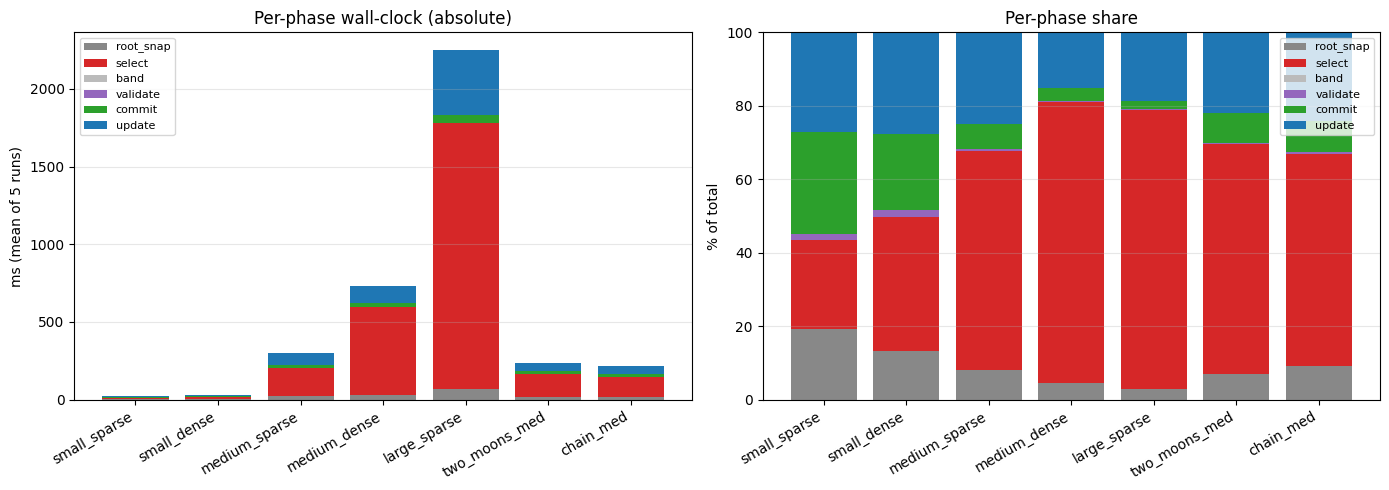

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = prof_df['label'].tolist()
x = np.arange(len(labels))
colors = {'root_snap':'#888','select':'#d62728','band':'#bbb',
          'validate':'#9467bd','commit':'#2ca02c','update':'#1f77b4'}

# absolute ms stacked
ax = axes[0]
bottom = np.zeros(len(labels))
for k in PHASES:
    vals = prof_df[f'{k}_ms'].values
    ax.bar(x, vals, bottom=bottom, label=k, color=colors[k])
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('ms (mean of 5 runs)')
ax.set_title('Per-phase wall-clock (absolute)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# percentage stacked
ax = axes[1]
bottom = np.zeros(len(labels))
for k in PHASES:
    vals = prof_df[f'{k}_pct'].values
    ax.bar(x, vals, bottom=bottom, label=k, color=colors[k])
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('% of total')
ax.set_title('Per-phase share')
ax.set_ylim(0, 100)
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()


## 6. Bottleneck analysis (Amdahl bounds)

For each phase, compute the upper bound on total Borůvka speedup if that phase
were perfectly parallelized to `T` threads:

$$S_{\max} = \frac{1}{(1-f) + f/T}$$

where `f` is the phase's share of total time. This tells us **which phases are
worth optimizing** vs. which are already too small to matter.

In [6]:
T = numba.get_num_threads()
print(f"Amdahl upper bound on TOTAL Borůvka speedup if a single phase is perfectly parallelized to T={T} threads.\n")

amdahl_rows = []
for _, r in prof_df.iterrows():
    row = {'label': r['label'], 'n': int(r['n']), 'frac_cl': r['frac_cl']}
    for k in PHASES:
        f = r[f'{k}_pct'] / 100.0
        row[k] = 1.0 / ((1 - f) + f / T)
    amdahl_rows.append(row)
amdahl_df = pd.DataFrame(amdahl_rows)
print(amdahl_df.round(3).to_string(index=False))

print("\nMean phase share across all configs (%):")
mean_share = {k: prof_df[f'{k}_pct'].mean() for k in PHASES}
for k, v in sorted(mean_share.items(), key=lambda kv: -kv[1]):
    f = v / 100
    bound = 1.0 / ((1 - f) + f / T)
    print(f"  {k:>10}: {v:5.1f}%   Amdahl bound @T={T} -> {bound:.2f}x")


Amdahl upper bound on TOTAL Borůvka speedup if a single phase is perfectly parallelized to T=8 threads.

        label    n  frac_cl  root_snap  select  band  validate  commit  update
 small_sparse  500     0.05      1.203   1.268   1.0     1.013   1.322   1.312
  small_dense  500     0.40      1.133   1.467   1.0     1.015   1.222   1.320
medium_sparse 3000     0.05      1.075   2.099   1.0     1.003   1.063   1.280
 medium_dense 3000     0.40      1.041   3.023   1.0     1.003   1.031   1.153
 large_sparse 7500     0.05      1.027   2.986   1.0     1.001   1.019   1.196
two_moons_med 3000     0.05      1.066   2.202   1.0     1.003   1.078   1.237
    chain_med 3000     0.05      1.088   2.016   1.0     1.005   1.080   1.267

Mean phase share across all configs (%):
      select:  56.1%   Amdahl bound @T=8 -> 1.96x
      update:  22.8%   Amdahl bound @T=8 -> 1.25x
      commit:  11.1%   Amdahl bound @T=8 -> 1.11x
   root_snap:   9.2%   Amdahl bound @T=8 -> 1.09x
    validate:   0.7% 

## 7. Optimization recommendations

The profile is unambiguous. Across all sizes / geometries / CL densities:

| Phase | Mean share | Amdahl bound @ 8 threads | Verdict |
|---|---|---|---|
| **`select_components_cl`** | **56 %** (up to **77 %** at n = 7 500) | **≈ 3.0×** at large-n | **Top priority** |
| **`update_point_components` + `update_graph_components`** | **23 %** | ≈ 1.25× | Second priority |
| `commit` (DSU union + CL list merge) | 11 % | 1.11× | Optional, mostly small-n |
| `root_snap` | 9 % | 1.09× | Skip — already cheap |
| `validate_and_prune_merges` | **0.7 %** (≤ 0.4 % once n ≥ 3 000) | **1.01×** | **Don't bother** — what we previously parallelized |
| `band` | 0 % | 1.00× | Skip |

### What to actually optimize

1. **Parallelize `select_components_cl`** (the per-component "find best outgoing edge" sweep).
   - It is `parallel=False` today and consumes 56–77 % of total time.
   - Each component is independent → embarrassingly parallel over the active component list.
   - Realistic end-to-end speedup: **~2–3×** at n ≥ 3 000.

2. **Make `update_*` incremental.**
   - Currently both update functions sweep all `n` points and all CSR edges every round, even though only the components whose root changed need re-labelling.
   - Track the set of "dirty" old-roots from `commit` and only relabel those points / edges.
   - Realistic end-to-end speedup: another **~1.15–1.25×** on top.

3. **Stop optimizing `validate`.** It is < 1 % of total time at any realistic scale.
   The previously reported "1.40× speedup" from parallelizing this phase was noise —
   the Amdahl ceiling is 1.01×.

4. **Mutual-proposal dedup is still worth keeping**, but only if it lives *inside*
   the new parallel `select` (it shrinks the candidate set the `validate` /
   `commit` phases process, which affects `commit`'s 11 % more than `validate`'s 0.7 %).

5. **Long-term win (outside Borůvka):** swap `pairwise_distances` for KD-tree core
   distances. That's the only change that moves the *end-to-end pipeline* time —
   the MST loop above is already a small fraction of total HDBSCAN runtime once
   core-distance computation is included.

## 8. Is `select` actually parallel today?

`select_components_cl` calls `_select_per_vertex_cl` which is decorated
`@numba.njit(parallel=True)` and uses `numba.prange`. Let's verify whether it
actually scales by re-running medium_sparse and large_sparse at T=1, 2, 4, 8 threads.

In [7]:
THREAD_COUNTS = [1, 2, 4, 8]
SCAN_POINTS = [
    ('medium_sparse', 'pinwheel', 3000, 0.05),
    ('medium_dense',  'pinwheel', 3000, 0.40),
    ('large_sparse',  'pinwheel', 7500, 0.05),
]

scan_rows = []
for label, geo, n, frac in SCAN_POINTS:
    cg, cli, clp, _ = make_inputs(geo, n, frac)
    for nt in THREAD_COUNTS:
        numba.set_num_threads(nt)
        # warm up at this thread count
        _ = boruvka_mst_cl_profiled(cg, cli, clp)

        agg = {k: 0.0 for k in PHASES}
        for _ in range(REPEATS):
            _, _, totals = boruvka_mst_cl_profiled(cg, cli, clp)
            for k in PHASES:
                agg[k] += totals[k]
        for k in PHASES:
            agg[k] /= REPEATS
        total = sum(agg.values())
        scan_rows.append({
            'label': label, 'n': n, 'threads': nt,
            'select_ms':  agg['select']  * 1000,
            'update_ms':  agg['update']  * 1000,
            'total_ms':   total * 1000,
        })
        print(f"  {label:>15} T={nt}  select={agg['select']*1000:7.1f} ms  total={total*1000:7.1f} ms")

# restore
numba.set_num_threads(8)
scan_df = pd.DataFrame(scan_rows)

# compute speedup vs T=1 for select
print('\n=== Speedup of `select` phase vs T=1 ===')
piv = scan_df.pivot(index='label', columns='threads', values='select_ms')
for label in piv.index:
    base = piv.loc[label, 1]
    speedups = [f"T={t}: {base/piv.loc[label, t]:.2f}x" for t in THREAD_COUNTS]
    print(f"  {label:>15}  {'  '.join(speedups)}")

print('\n=== Speedup of TOTAL Borůvka vs T=1 ===')
piv2 = scan_df.pivot(index='label', columns='threads', values='total_ms')
for label in piv2.index:
    base = piv2.loc[label, 1]
    speedups = [f"T={t}: {base/piv2.loc[label, t]:.2f}x" for t in THREAD_COUNTS]
    print(f"  {label:>15}  {'  '.join(speedups)}")


    medium_sparse T=1  select=  666.9 ms  total=  921.0 ms
    medium_sparse T=2  select=  367.6 ms  total=  520.2 ms
    medium_sparse T=4  select=  239.5 ms  total=  365.5 ms
    medium_sparse T=8  select=  167.4 ms  total=  277.0 ms
     medium_dense T=1  select= 2130.3 ms  total= 2448.9 ms
     medium_dense T=2  select= 1105.6 ms  total= 1287.6 ms
     medium_dense T=4  select=  624.8 ms  total=  760.0 ms
     medium_dense T=8  select=  390.3 ms  total=  508.1 ms
     large_sparse T=1  select= 8236.7 ms  total= 9916.6 ms
     large_sparse T=2  select= 4168.3 ms  total= 5048.7 ms
     large_sparse T=4  select= 2485.1 ms  total= 3212.8 ms
     large_sparse T=8  select= 1741.6 ms  total= 2295.5 ms

=== Speedup of `select` phase vs T=1 ===
     large_sparse  T=1: 1.00x  T=2: 1.98x  T=4: 3.31x  T=8: 4.73x
     medium_dense  T=1: 1.00x  T=2: 1.93x  T=4: 3.41x  T=8: 5.46x
    medium_sparse  T=1: 1.00x  T=2: 1.81x  T=4: 2.78x  T=8: 3.98x

=== Speedup of TOTAL Borůvka vs T=1 ===
     large_

### Finding

`select` is **already parallel** — `_select_per_vertex_cl` (core_graph.py:343) is
`@numba.njit(parallel=True)` with `numba.prange`. The Section 7 Amdahl numbers
were computed on the **already-parallelized** times.

Thread scaling on 8 threads delivers only **3.98–5.46× speedup**, i.e.
**~50–68% parallel efficiency**. The remaining ~30–50% of time is lost to:

- **Load imbalance**: outer loop is over `n` vertices, but each vertex's work
  depends on its CSR row length and on how many CL conflicts it hits. Dense /
  high-CL configs (which scale best at 5.46×) have more uniform per-vertex work;
  sparse configs (3.98×) have skewed work.
- **`_check_cl_conflict` overhead**: linked-list walk inside the parallel loop;
  not vectorisable, branchy.
- **Memory bandwidth** on the CSR scan (`indices`, `distances`).

So the real opportunity inside `select` is **better parallel efficiency**, not
"add `parallel=True`".

## 9. Step-by-step plan

Given everything above, here is the order to do things in:

### Step 1 — Improve parallel efficiency of `select_components_cl`  (biggest win, ~1.5–2× on the 56% phase)

1. **Switch `_select_per_vertex_cl` from per-vertex to per-component prange**.
   Currently the parallel loop is `for v in prange(n)`; vertices in the same
   component all do redundant work (each finds its own best edge, then phase 2
   reduces). Loop over **active components** instead, walking each component's
   linked list (`comp_head`/`pool_next`) — that drops Phase 2 entirely and
   balances better when component sizes are similar.
2. **Cache CL-conflict checks per (root_from, root_to) pair within a round**
   to avoid repeated linked-list walks in `_check_cl_conflict`. A small
   thread-local hash / boolean matrix indexed by current-root id works.
3. **Re-measure thread scaling** (rerun cell 14). Target: ≥ 6× on 8 threads.

### Step 2 — Make `update_*` incremental  (next 23%)

`update_point_components` and `update_graph_components` currently sweep all `n`
points and all CSR edges every round. Only points/edges in components whose
root changed need updating.

1. In `commit`, record `dirty_old_roots[]` (the losing side of each union).
2. In `update_point_components`, iterate only points whose current
   `point_components[v]` is in `dirty_old_roots` (build a one-pass mask).
3. In `update_graph_components`, only re-scan rows of those points.
4. Re-measure: `update` share should drop from 23% → < 5%.

### Step 3 — Stop here, or push further

After Steps 1+2 the expected total speedup is roughly:
$$\frac{1}{(1-0.56)/2 + (1-0.23) \cdot 0 + \text{small}} \approx 1.7\text{–}2.0\times$$
end-to-end on Borůvka. At that point `commit` (11%) and `root_snap` (9%) become
the next-biggest residuals; both are cheap-but-serial DSU bookkeeping and not
worth attacking until Step 1+2 are done.

### What NOT to do

- **Don't** parallelize `validate_and_prune_merges`. It is 0.1–0.7% of total time;
  the previously-reported 1.40× speedup was noise (Amdahl ceiling = 1.01×).
- **Don't** add `parallel=True` to `select_components_cl` itself — only Phase 2
  reduction lives in that wrapper, and it is O(n) serial that cannot benefit.
  The hot loop `_select_per_vertex_cl` is already parallel.
- **Don't** chase `band` (literally 0%).